In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader,Dataset
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
!pip install optuna

In [ ]:
torch.manual_seed(42)

In [ ]:
#check for GPU
print(torch.__version__)
print(torch.__file__)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
import sys
print(sys.executable)

2.11.0+cu128
/usr/local/lib/python3.12/dist-packages/torch/__init__.py
cuda
/usr/bin/python3


In [ ]:
df=pd.read_csv('fashion-mnist_train.csv')
df.head()


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


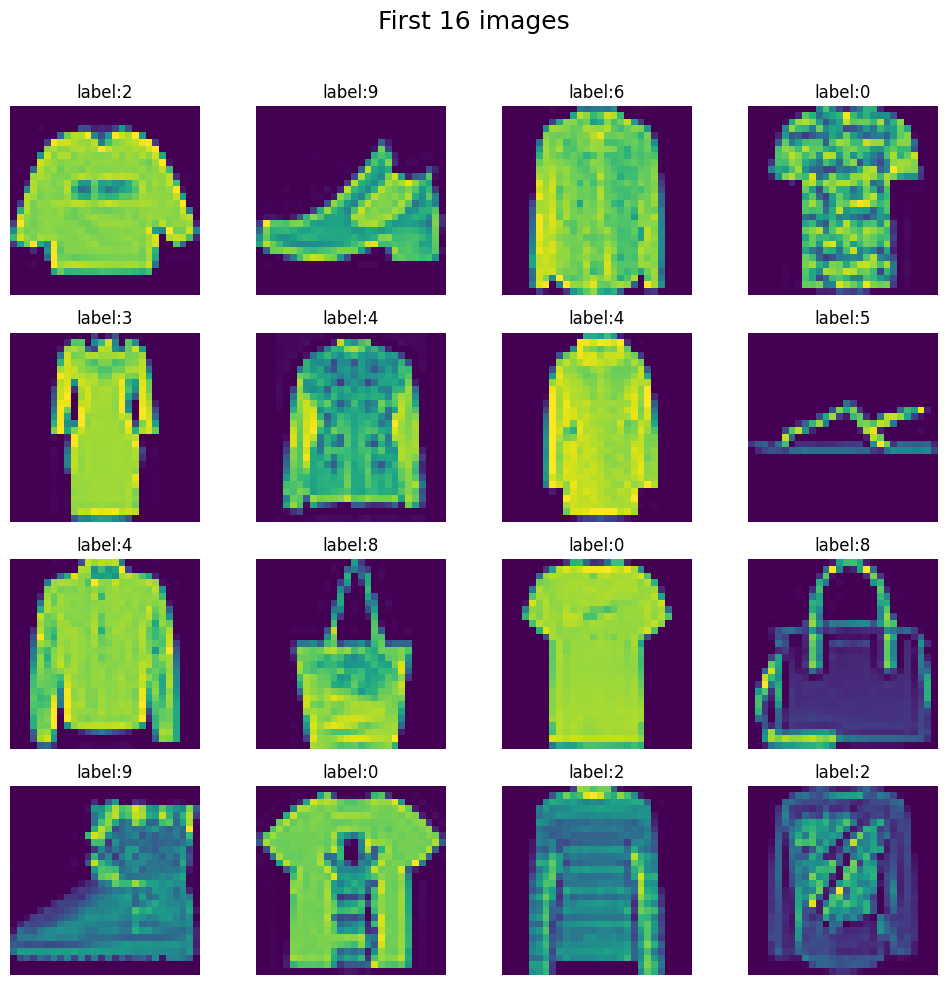

In [ ]:
#create 4x4 grid images
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 images",fontsize=18)
#now plot the 16 images from the dataset
for i,ax in enumerate(axes.flat):
    img=df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)  #display in grayscale
    ax.axis('off') #this is just removing the axes
    ax.set_title(f"label:{df.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1,0.96])  #adjust layout to fit the title
plt.show()


In [ ]:
#train_test_split
X=df.iloc[:,1:].values
y=df.iloc[:,0].values


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#scaling the features
X_train=X_train/255.0
X_test=X_test/255.0

In [ ]:
#create CustomDataset class
class CustomDataset(Dataset):
  def __init__(self,X,y,device):
    self.features=torch.tensor(X, dtype=torch.float32).to(device)
    self.labels=torch.tensor(y, dtype=torch.long).to(device)
  def __len__(self):
    return len(self.features)
  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]

In [ ]:
#create train_dataset obj
train_dataset=CustomDataset(X_train,y_train,device)

In [ ]:
#create test_dataset obj
test_dataset=CustomDataset(X_test,y_test,device)

In [ ]:
class MyNN(nn.Module):
    def __init__(self,input_dim,output_dim,num_hidden_layers,neurons_per_layer,dropout_rate):
        super().__init__()
        layers=[]
        for i in range(num_hidden_layers):
            layers.append(nn.Linear(input_dim,neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_dim=neurons_per_layer
        layers.append(nn.Linear(neurons_per_layer,output_dim))
        self.model=nn.Sequential(*layers)

    def forward(self,x):
        return self.model(x)

In [ ]:
#objective function

def Objective(trial):
    #hyperparameter values from search space
    num_hidden_layers=trial.suggest_int("num_hidden_layers",1,10)
    neurons_per_layer=trial.suggest_int("neurons_per_layer",8,512,step=8)
    epochs=trial.suggest_int("epochs",10,50,step=10)
    learning_rate=trial.suggest_float("learning_rate",1e-5,1e-1,log=True)
    dropout_rate=trial.suggest_float("dropout_rate",0.1,0.5,step=0.1)
    batch_size=trial.suggest_categorical("batch_size",[16,32,64,128])
    optimizer_name=trial.suggest_categorical("optimizer",['Adam','SGD','RMSprop'])
    weight_decay=trial.suggest_float("weight_decay",1e-5,1e-3,log=True)
    #create train and test loder
    train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
    test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False) #we dont want to shuffle when predicting

    #model init
    input_dim=784
    output_dim=10
    model=MyNN(input_dim,output_dim,num_hidden_layers,neurons_per_layer,dropout_rate)
    model.to(device)
    #optimizer selction

    loss_fun=nn.CrossEntropyLoss()
    #optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)

    if optimizer_name=='Adam':
      optimizer=optim.Adam(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
    elif optimizer_name=='SGD':
      optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
    else:
      optimizer=optim.RMSprop(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
    #training loop
    #training loop
    for epoch in range(epochs):
      for batch_features,batch_labels in train_loader:
        #move data to gpu
        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
        #forward pass
        out=model(batch_features)
        #calcualte loss
        loss=loss_fun(out,batch_labels)

        #backward pass
        optimizer.zero_grad()
        loss.backward()
        #optimizer-update the grads
        optimizer.step()

     #evaluation
    model.eval()
    #eval code
    total=0
    correct=0
    with torch.no_grad():
      for batch_features,batch_labels in test_loader:
         #move data to gpu
        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
        out=model(batch_features)
        _,predicted=torch.max(out,1)
        total=total+batch_labels.shape[0]
        correct=correct+(predicted==batch_labels).sum().item()
    accuracy=correct/total

    return accuracy

In [ ]:
import optuna
study=optuna.create_study(direction='maximize')

[I 2026-06-25 13:53:14,585] A new study created in memory with name: no-name-1a6b39cd-288c-4bc3-bb19-bd132f181d90


In [ ]:
study.optimize(Objective,n_trials=30)

[I 2026-06-25 13:58:09,367] Trial 0 finished with value: 0.8809166666666667 and parameters: {'num_hidden_layers': 8, 'neurons_per_layer': 224, 'epochs': 20, 'learning_rate': 0.0005536179114327654, 'dropout_rate': 0.30000000000000004, 'batch_size': 16, 'optimizer': 'Adam', 'weight_decay': 0.00010535207492709382}. Best is trial 0 with value: 0.8809166666666667.
[I 2026-06-25 13:58:41,207] Trial 1 finished with value: 0.87625 and parameters: {'num_hidden_layers': 6, 'neurons_per_layer': 360, 'epochs': 20, 'learning_rate': 0.012042389191276504, 'dropout_rate': 0.4, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0002042454734468032}. Best is trial 0 with value: 0.8809166666666667.
[I 2026-06-25 13:59:34,916] Trial 2 finished with value: 0.8711666666666666 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 168, 'epochs': 10, 'learning_rate': 0.0001131442517647192, 'dropout_rate': 0.4, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.00017642815828083802}. Best is

In [ ]:
study.best_value

0.90425

In [ ]:
study.best_params

{'num_hidden_layers': 3,
 'neurons_per_layer': 464,
 'epochs': 50,
 'learning_rate': 6.29678165759005e-05,
 'dropout_rate': 0.2,
 'batch_size': 16,
 'optimizer': 'Adam',
 'weight_decay': 1.5123734208632638e-05}